## ThinkDSP

This notebook contains code examples from Chapter 4: Noise

Copyright 2015 Allen Downey

License: [Creative Commons Attribution 4.0 International](http://creativecommons.org/licenses/by/4.0/)

In [30]:
from os.path import basename, exists

def download(url, filename):
    if not exists(filename):
        from urllib.request import urlretrieve
        local, _ = urlretrieve(url, filename)
        print("Downloaded " + local)
    else:
        print(f"{filename} already exists")

download("https://github.com/AllenDowney/ThinkDSP/raw/master/thinkdsp/thinkdsp.py", "thinkdsp.py")


thinkdsp.py already exists


In [31]:
import numpy as np
import matplotlib.pyplot as plt

from thinkdsp import decorate

In [32]:
np.random.seed(17)

The simplest noise to generate is uncorrelated uniform (UU) noise:

In [33]:
from thinkdsp import UncorrelatedUniformNoise

signal = UncorrelatedUniformNoise()
wave = signal.make_wave(duration=0.5, framerate=11025)
wave.make_audio()

Here's what a segment of it looks like:

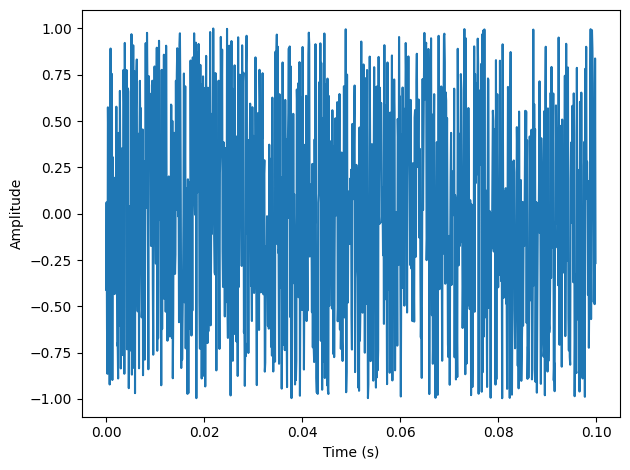

In [34]:
segment = wave.segment(duration=0.1)
segment.plot()
decorate(xlabel='Time (s)',
         ylabel='Amplitude')

And here's the spectrum:

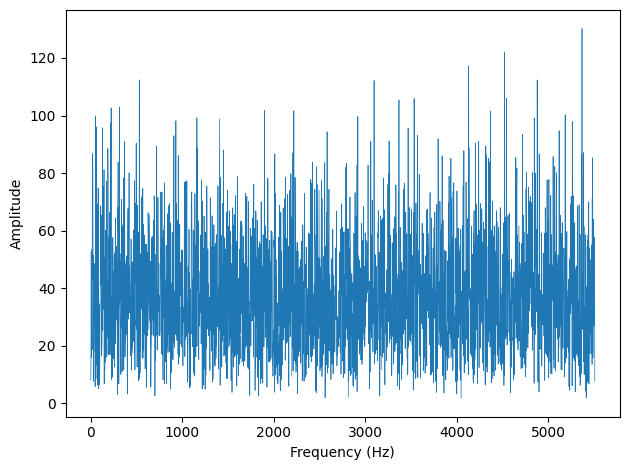

In [35]:
spectrum = wave.make_spectrum()
spectrum.plot(linewidth=0.5)
decorate(xlabel='Frequency (Hz)',
         ylabel='Amplitude')

In the context of noise it is more conventional to look at the spectrum of power, which is the square of amplitude:

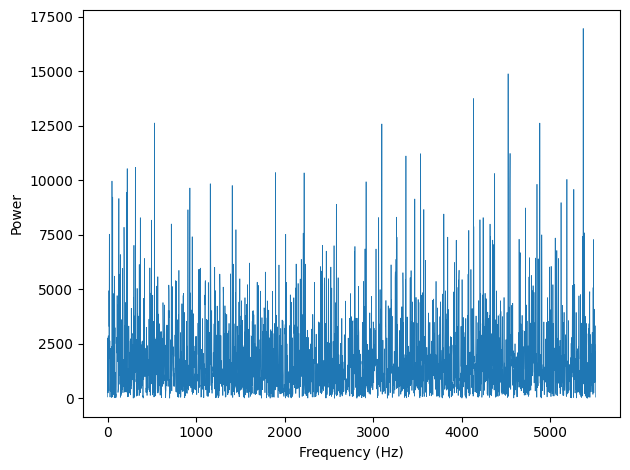

In [36]:
spectrum.plot_power(linewidth=0.5)
decorate(xlabel='Frequency (Hz)',
         ylabel='Power')

UU noise has the same power at all frequencies, on average, which we can confirm by looking at the normalized cumulative sum of power, which I call an integrated spectrum:

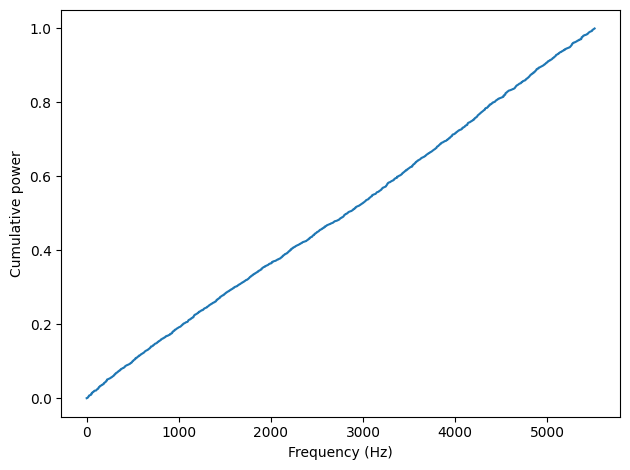

In [37]:
integ = spectrum.make_integrated_spectrum()
integ.plot_power()
decorate(xlabel='Frequency (Hz)',
         ylabel='Cumulative power')

A straight line in this figure indicates that UU noise has equal power at all frequencies, on average.  By analogy with light, noise with this property is called "white noise".

### Brownian noise

Brownian noise is generated by adding up a sequence of random steps.

In [38]:
from thinkdsp import BrownianNoise

signal = BrownianNoise()
wave = signal.make_wave(duration=0.5, framerate=11025)
wave.make_audio()

The sound is less bright, or more muffled, than white noise.

Here's what the wave looks like:

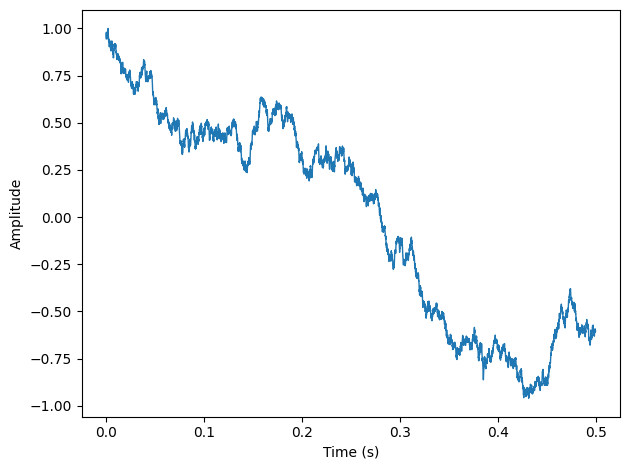

In [39]:
wave.plot(linewidth=1)
decorate(xlabel='Time (s)',
         ylabel='Amplitude')

Here's what the power spectrum looks like on a linear scale.

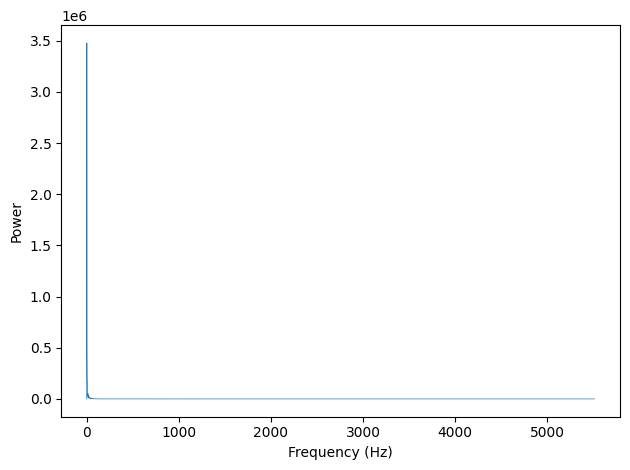

In [40]:
spectrum = wave.make_spectrum()
spectrum.plot_power(linewidth=0.5)
decorate(xlabel='Frequency (Hz)',
         ylabel='Power')

So much of the energy is at low frequencies, we can't even see the high frequencies.

We can get a better view by plotting the power spectrum on a log-log scale.

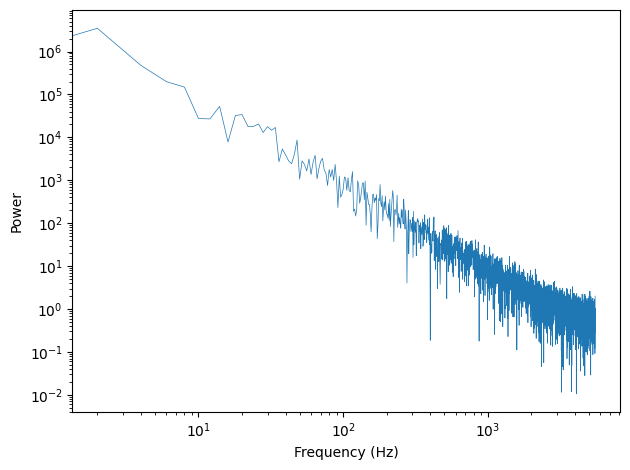

In [41]:
# The f=0 component is very small, so on a log scale
# it's very negative.  If we clobber it before plotting,
# we can see the rest of the spectrum more clearly.
spectrum.hs[0] = 0

spectrum.plot_power(linewidth=0.5)

loglog = dict(xscale='log', yscale='log')
decorate(xlabel='Frequency (Hz)',
         ylabel='Power',
         **loglog)

Now the relationship between power and frequency is clearer.  The slope of this line is approximately -2, which indicates that $P = K / f^2$, for some constant $K$.

In [42]:
signal =  BrownianNoise()
wave = signal.make_wave(duration=0.5, framerate=11025)
spectrum = wave.make_spectrum()
result = spectrum.estimate_slope()
result.slope

np.float64(-1.7846032211221767)

The estimated slope of the line is closer to -1.8 than -2, for reasons we'll see later.

### Pink noise

Pink noise is characterized by a parameter, $\beta$, usually between 0 and 2.  You can hear the differences below.

With $\beta=0$, we get white noise:

In [43]:
from thinkdsp import PinkNoise

signal = PinkNoise(beta=0)
wave = signal.make_wave(duration=0.5)
wave.make_audio()

With $\beta=1$, pink noise has the relationship $P = K / f$, which is why it is also called $1/f$ noise.

In [44]:
signal = PinkNoise(beta=1)
wave = signal.make_wave(duration=0.5)
wave.make_audio()

With $\beta=2$, we get Brownian (aka red) noise.

In [45]:
signal = PinkNoise(beta=2)
wave = signal.make_wave(duration=0.5)
wave.make_audio()

The following figure shows the power spectrums for white, pink, and red noise on a log-log scale.

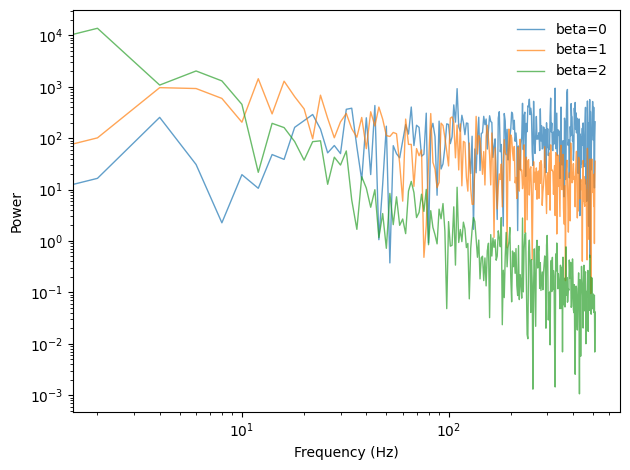

In [46]:
betas = [0, 1, 2]

for beta in betas:
    signal = PinkNoise(beta=beta)
    wave = signal.make_wave(duration=0.5, framerate=1024)
    spectrum = wave.make_spectrum()
    spectrum.hs[0] = 0
    label = f'beta={beta}'
    spectrum.plot_power(linewidth=1, alpha=0.7, label=label)

decorate(xlabel='Frequency (Hz)',
         ylabel='Power',
         **loglog)

### Uncorrelated Gaussian noise

An alternative to UU noise is uncorrelated Gaussian (UG noise).

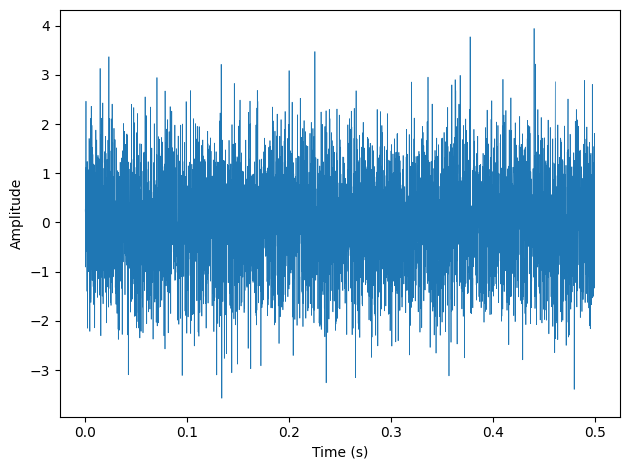

In [47]:
from thinkdsp import UncorrelatedGaussianNoise

signal = UncorrelatedGaussianNoise()
wave = signal.make_wave(duration=0.5, framerate=11025)
wave.plot(linewidth=0.5)
decorate(xlabel='Time (s)',
         ylabel='Amplitude')

The spectrum of UG noise is also UG noise.

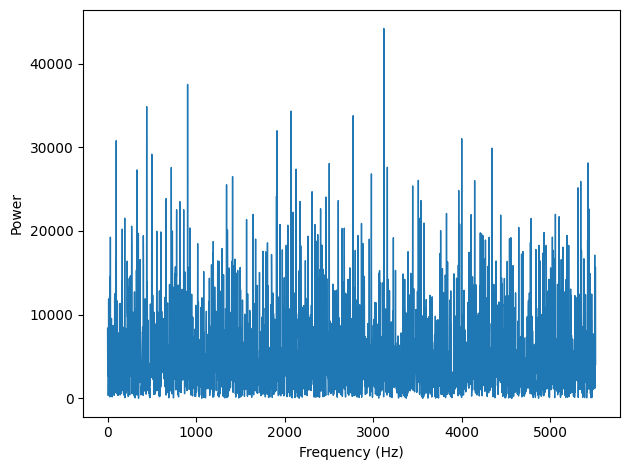

In [48]:
spectrum = wave.make_spectrum()
spectrum.plot_power(linewidth=1)
decorate(xlabel='Frequency (Hz)',
         ylabel='Power')

We can use a normal probability plot to test the distribution of the power spectrum.

In [49]:
def normal_prob_plot(sample, fit_color='0.8', **options):
    """Makes a normal probability plot with a fitted line.

    sample: sequence of numbers
    fit_color: color string for the fitted line
    options: passed along to Plot
    """
    n = len(sample)
    xs = np.random.normal(0, 1, n)
    xs.sort()

    ys = np.sort(sample)

    mean, std = np.mean(sample), np.std(sample)
    fit_ys = mean + std * xs
    plt.plot(xs, fit_ys, color='gray', alpha=0.5, label='model')

    plt.plot(xs, ys, **options)

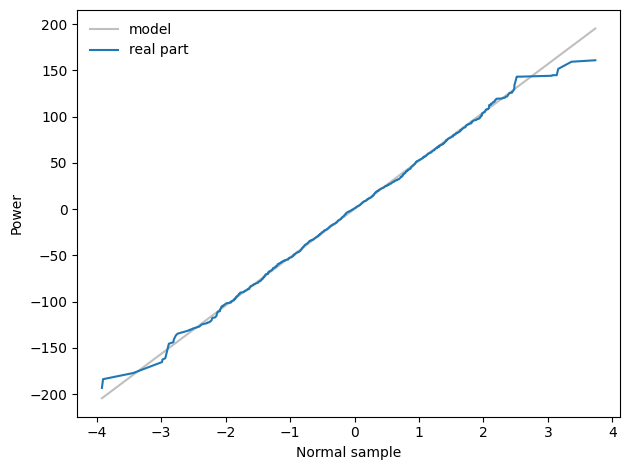

In [50]:
normal_prob_plot(spectrum.real, color='C0', label='real part')
decorate(xlabel='Normal sample',
         ylabel='Power')

A straight line on a normal probability plot indicates that the distribution of the real part of the spectrum is Gaussian.

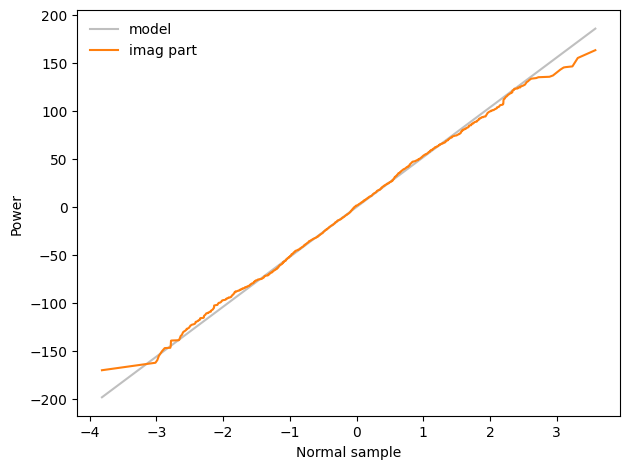

In [51]:
normal_prob_plot(spectrum.imag, color='C1', label='imag part')
decorate(xlabel='Normal sample',
         ylabel='Power')

And so is the imaginary part.

#Exercise 4.2

In [52]:
#we take a wave, split it up into segments
# plo t the power


def compute_average_power(wave, seg_length):
    i, j = 0, seg_length
    power_map = {}

    while j < len(wave.ys):
        segment = wave.slice(i,j)

        spec = segment.make_spectrum()

        for k in range(len(spec.power)):
            power_map[k] = power_map.get(k, 0) + spec.power[k]

        i += seg_length
        j += seg_length


    for power in power_map:
        power_map[power] /= (len(wave.ys)/seg_length)

    return power_map

    # could hjust use the make_spectogram function to extract the spectrums

    # and then map each specetum to their power disitrbution

    # and then get the amplitude for each by using np.sqrt over the array of power arrays
    # get frequnecy but just getting the first items freuqency bins (arequency bins are the same)





In [53]:
noise = UncorrelatedUniformNoise()
wave = signal.make_wave(duration=10000, framerate=11025)
wave.make_audio()

Output hidden; open in https://colab.research.google.com to view.

In [54]:
compute_average_power(wave, 512)

{0: np.float64(510.77957464319235),
 1: np.float64(513.1837623819883),
 2: np.float64(511.1337132980035),
 3: np.float64(512.1733392955633),
 4: np.float64(512.5200603345113),
 5: np.float64(514.814765601545),
 6: np.float64(511.0523477357188),
 7: np.float64(510.38000499315183),
 8: np.float64(510.2876368427112),
 9: np.float64(511.7898193887125),
 10: np.float64(512.2493900109159),
 11: np.float64(512.2597282501575),
 12: np.float64(510.9776046169747),
 13: np.float64(511.2158658609663),
 14: np.float64(512.3783109500505),
 15: np.float64(511.3302499130277),
 16: np.float64(512.5122203841943),
 17: np.float64(511.27912586842973),
 18: np.float64(509.38619028116045),
 19: np.float64(512.6543880837494),
 20: np.float64(512.0658616686874),
 21: np.float64(511.82578269918105),
 22: np.float64(512.7166064495324),
 23: np.float64(511.2201527665482),
 24: np.float64(511.0124907565979),
 25: np.float64(513.3835821519417),
 26: np.float64(513.5579567444817),
 27: np.float64(511.4653723497595)

#Exericse 4.3

In [55]:
download("https://github.com/AllenDowney/ThinkDSP/raw/master/soln/BTC_USD_2013-10-01_2020-03-26-CoinDesk.csv", "BTC-coindesk.csv")

BTC-coindesk.csv already exists


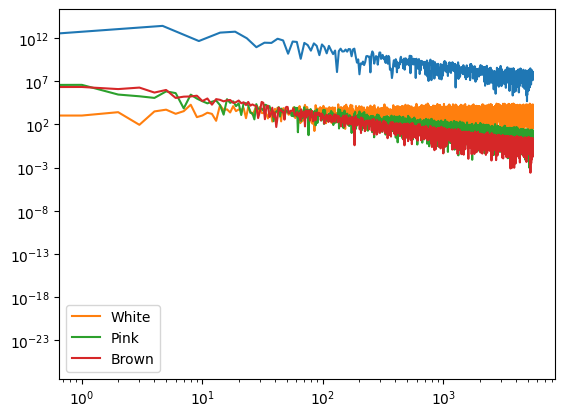

BTC Stats: LinregressResult(slope=np.float64(-1.7332540936758936), intercept=np.float64(31.81549486562035), rvalue=np.float64(-0.7974641205174432), pvalue=np.float64(1.616191018170776e-260), stderr=np.float64(0.038224688145599546), intercept_stderr=np.float64(0.2936329970591295))
BTC Stats: LinregressResult(slope=np.float64(-0.005634805226665843), intercept=np.float64(7.679400428732601), rvalue=np.float64(-0.004323817682791399), pvalue=np.float64(0.7482549366638627), stderr=np.float64(0.017556246758283156), intercept_stderr=np.float64(0.1348403898541222))
BTC Stats: LinregressResult(slope=np.float64(-1.4834484910816552), intercept=np.float64(13.694843229509381), rvalue=np.float64(-0.7580955849273213), pvalue=np.float64(0.0), stderr=np.float64(0.017191582015205598), intercept_stderr=np.float64(0.13204113607424853))
BTC Stats: LinregressResult(slope=np.float64(-1.8047148515523497), intercept=np.float64(14.555316202720103), rvalue=np.float64(-0.8680703944688973), pvalue=np.float64(0.0), s

In [56]:
# this sort of shit where it feels like AI can do it how to apporach


# at the very least understand what the operations are that you ened to do

# understand how those work ---> basically have everything down eccept suytntax us tbe able to understand/write the function inpseudocoe and udnerstand the implementation of functions

from thinkdsp import Wave

import pandas as pd

df = pd.read_csv('BTC-coindesk.csv')
df.columns

wave = Wave(df['Closing Price (USD)'], df['Date'])

wave_uncorr = UncorrelatedUniformNoise().make_wave()
uncorr_spec = wave_uncorr.make_spectrum()

pink = PinkNoise(beta = 1.5).make_wave()
pink_spec = pink.make_spectrum()

brown = BrownianNoise().make_wave()
brown_spec = brown.make_spectrum()


spec = wave.make_spectrum()


spec.hs[0] = 0
spec.plot_power()
uncorr_spec.plot_power(label="White")
pink_spec.plot_power(label="Pink")
brown_spec.plot_power(label="Brown")

plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.show()

print(f"BTC Stats: {spec.estimate_slope()}")
print(f"BTC Stats: {uncorr_spec.estimate_slope()}")
print(f"BTC Stats: {pink_spec.estimate_slope()}")
print(f"BTC Stats: {brown_spec.estimate_slope()}")



# wave = wav(df[])

# read the csv


# inspect the cols...

# looka t the arugments that a wave takes and then convert the bitcoin data to wa ve

# run the spectum thing plot it --- look at the relationship between power and frequency

# care about slope



#Exercise 4.4

In [85]:
from thinkdsp import Noise, normalize, unbias
from numpy import random

class UncorrelatedPoissonNoise(Noise):
    def evaluate(self, ts):
        samples = random.poisson(lam=self.amp, size=len(ts))
        return samples




In [116]:
signal = UncorrelatedPoissonNoise(amp=0.001)
wave = signal.make_wave(duration=1)

wave.make_audio()

expected = 0.001 * 11025
actual = sum(wave.ys)

print(expected, actual)

11.025 9


LinregressResult(slope=np.float64(-0.023666627448045596), intercept=np.float64(8.211025421024116), rvalue=np.float64(-0.018554372247981215), pvalue=np.float64(0.330204377102973), stderr=np.float64(0.02430151627635026), intercept_stderr=np.float64(0.1866601461493605))

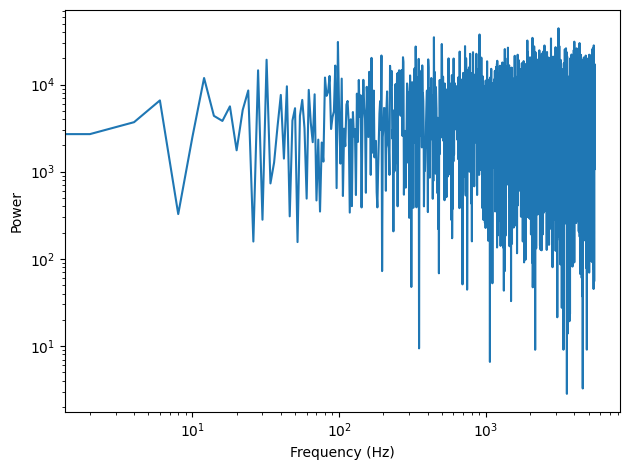

In [118]:
spectum = wave.make_spectrum()
spectrum.plot_power()
decorate(xlabel='Frequency (Hz)',
         ylabel='Power',
         **loglog)

spectrum.estimate_slope()

sample interval is the time ebtween the the adjacent time stamps/samples, lambda tells us the average number of particles in thoseintervlas. Expected particles per second = expected particles per smaple interval x sample intervals per seocnd . Noise - less predictable sdoens't have the harmonic compoenets of periodic

#Exercise 4.5  Voss-McCartney Implementaiton from Wikipedia

In [95]:
#https://en.wikipedia.org/wiki/Pink_noise search VOss-Mccartney

# output is the amplitude
def Voss_McCart(n_streams, total_samples):
    output = []
    streams = [random.random() for _ in range(n_streams)]

    for i in range(total_samples):
        for j in range(n_streams):
            if i % (2**j) == 0:
                streams[j] = random.random()
        output.append(sum(streams))

    return output

class Voss_Pink(Noise):
    def __init__(self, ampl=1.0, n_streams = 5):
        self.ampl = ampl
        self.n_streams = n_streams

    # evalaute is used to make the wave i guess? it takes timestamps gets the ys and then calls makewave

    def evaluate(self, ts):
        ys = Voss_McCart(self.n_streams, len(ts))
        return ys




# plot the spectrunm
# plot the power
# estimate teh sloe



LinregressResult(slope=np.float64(-1.0433945392395614), intercept=np.float64(15.387851565518446), rvalue=np.float64(-0.6322236521773247), pvalue=np.float64(0.0), stderr=np.float64(0.017225972599662402), intercept_stderr=np.float64(0.13230372601473106))

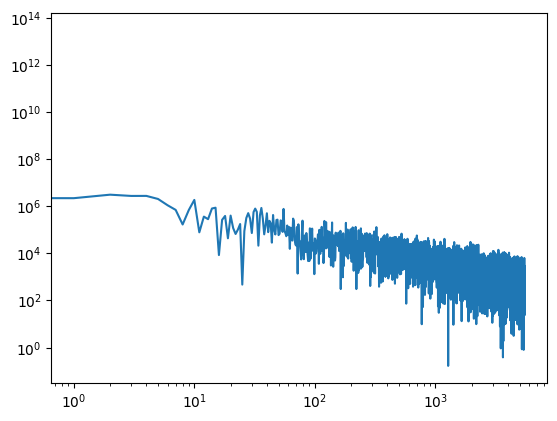

In [112]:
from thinkdsp import PinkNoise

pink = Voss_Pink(ampl=3.0, n_streams = 1000)
pink2 = PinkNoise(amp=3.0)

wave = pink.make_wave(duration=1)

wave2 = pink.make_wave(duration=1)
wave.make_audio()

spec1= wave.make_spectrum()
spec1.plot_power()

plt.xscale('log')
plt.yscale('log')


spec1.estimate_slope()

LinregressResult(slope=np.float64(-1.0392118025736539), intercept=np.float64(15.382651406059779), rvalue=np.float64(-0.6212040080382348), pvalue=np.float64(0.0), stderr=np.float64(0.017661010300270123), intercept_stderr=np.float64(0.13564502406999504))

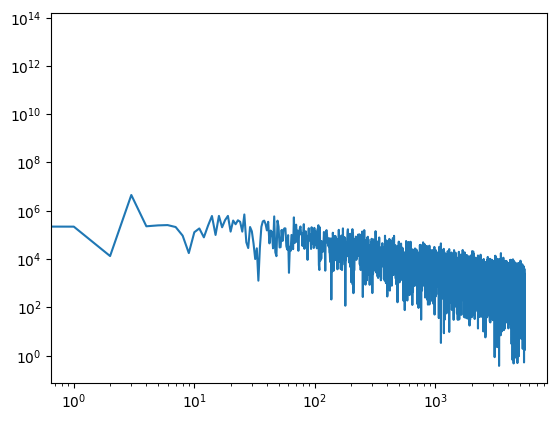

In [113]:
wave2.make_audio()
spec2 = wave2.make_spectrum()
spec2.plot_power()

plt.xscale('log')
plt.yscale('log')

spec2.estimate_slope()
